# 基于健身房运动表现数据预测各类型运动影响

## 准备数据

导库

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats

读取数据集

In [2]:
original_data = pd.read_csv('./data/gym_members_exercise_tracking.csv')
original_data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
original_data['Workout_Type'].unique()

array(['Yoga', 'HIIT', 'Cardio', 'Strength'], dtype=object)

Yoga指的是 瑜伽  \
HIIT 指的是 高强度间歇训练 \
Cardio 指的是 有氧运动 \
Strength 指的是 力量训练 

以下是一个总结这四种运动对身体不同影响的表格：
| 运动类型 | 主要影响 | 其他影响 |
| --- | --- | --- |
| 瑜伽 | 提高柔韧性、平衡性和力量 | 减轻压力、提高心理福祉、改善呼吸和心血管健康、提高协调性 |
| 高强度间歇训练 | 提高心肺功能和代谢率 | 燃烧脂肪、减少体重、提高肌肉耐力、提高适应能力和运动表现 |
| 有氧运动 | 提高心肺功能 | 燃烧脂肪、减少体重、提高耐力、降低患慢性疾病的风险 |
| 力量训练 | 增加肌肉力量和耐力 | 提高代谢率、增加肌肉质量和骨密度、改善姿态和平衡性、减少受伤风险 |


对字符串类型映射转换，方便后期处理

In [4]:
gender_reflection = {
    'Male': 1,
    'Female': 2
}
workout_type_reflection = {
    'Yoga': 1,
    'HIIT': 2,
    'Strength': 3,
    'Cardio': 4
}
data = original_data.copy()
data['Gender'] = original_data['Gender'].map(gender_reflection)
data['Workout_Type'] = original_data['Workout_Type'].map(workout_type_reflection)
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,1,12.6,3.5,4,3,30.20
1,46,2,74.9,1.53,179,151,66,1.30,883.0,2,33.9,2.1,4,2,32.00
2,32,2,68.1,1.66,167,122,54,1.11,677.0,4,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,3,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,3,29.2,2.8,3,1,14.39


## 数据分析

分析各类锻炼的比重

In [5]:
series_workout_type = original_data['Workout_Type'].value_counts()
series_workout_type.dtype, series_workout_type

(dtype('int64'),
 Workout_Type
 Strength    258
 Cardio      255
 Yoga        239
 HIIT        221
 Name: count, dtype: int64)

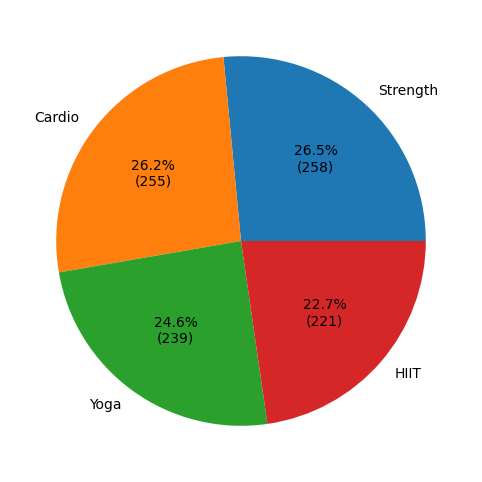

In [6]:
plt.figure(figsize=(10, 6))
def pie_pct_func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)
plt.pie(series_workout_type, labels=series_workout_type.index,
        autopct=lambda pct: pie_pct_func(pct, series_workout_type))
plt.show()

分析性别所占的比重

In [7]:
series_gender = original_data['Gender'].value_counts()
series_gender.dtype,series_gender

(dtype('int64'),
 Gender
 Male      511
 Female    462
 Name: count, dtype: int64)

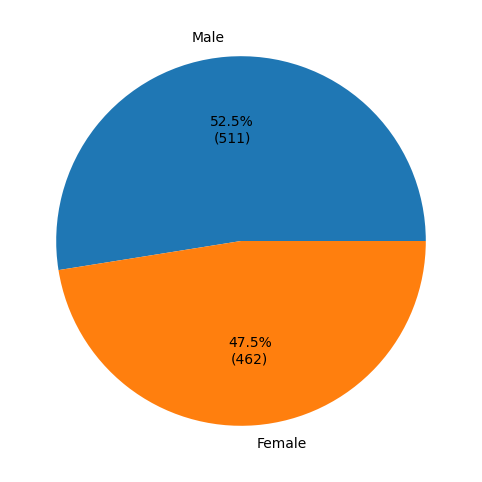

In [8]:
plt.figure(figsize=(10, 6))
plt.pie(series_gender, labels=series_gender.index,
        autopct=lambda pct: pie_pct_func(pct, series_gender))
plt.show()

计算相关系数

In [9]:
data.head(1)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,1,12.6,3.5,4,3,30.2


In [10]:
# 选择特定的列
feature_columns = ['Age', 'Height (m)', 'Max_BPM', 'Avg_BPM',
                   'Resting_BPM', 'Calories_Burned', 'Session_Duration (hours)',
                   'Water_Intake (liters)', 'Workout_Frequency (days/week)','Workout_Type']
label_columns = ['Weight (kg)', 'BMI', 'Fat_Percentage', 'Experience_Level']
X = data[feature_columns]
y = data[label_columns]
correlation_results = pd.DataFrame()
# 逐列计算相关性并存储
for col in y.columns:
    correlation_results[col] = X.corrwith(y[col])
correlation_results

,Weight (kg),BMI,Fat_Percentage,Experience_Level
Age,-0.036340,-0.013691,0.002370,-0.018676
Height (m),0.365321,-0.159469,-0.235521,-0.010267
Max_BPM,0.057061,0.067105,-0.009056,0.000545
Avg_BPM,0.009717,0.021605,-0.007302,-0.000888
Resting_BPM,-0.032138,-0.032543,-0.016834,0.001758
Calories_Burned,0.095443,0.059761,-0.597615,0.694129
Session_Duration (hours),-0.013666,-0.006493,-0.581520,0.764768
Water_Intake (liters),0.394276,0.213697,-0.588683,0.304104
Workout_Frequency (days/week),-0.011769,0.001645,-0.537060,0.837079
Workout_Type,0.002820,0.031594,0.066787,-0.061118


In [11]:
correlation_results.sort_values(by='Weight (kg)', ascending=False)

,Weight (kg),BMI,Fat_Percentage,Experience_Level
Water_Intake (liters),0.394276,0.213697,-0.588683,0.304104
Height (m),0.365321,-0.159469,-0.235521,-0.010267
Calories_Burned,0.095443,0.059761,-0.597615,0.694129
Max_BPM,0.057061,0.067105,-0.009056,0.000545
Avg_BPM,0.009717,0.021605,-0.007302,-0.000888
Workout_Type,0.002820,0.031594,0.066787,-0.061118
Workout_Frequency (days/week),-0.011769,0.001645,-0.537060,0.837079
Session_Duration (hours),-0.013666,-0.006493,-0.581520,0.764768
Resting_BPM,-0.032138,-0.032543,-0.016834,0.001758
Age,-0.036340,-0.013691,0.002370,-0.018676


In [12]:
correlation_results.sort_values(by='BMI', ascending=False)

,Weight (kg),BMI,Fat_Percentage,Experience_Level
Water_Intake (liters),0.394276,0.213697,-0.588683,0.304104
Max_BPM,0.057061,0.067105,-0.009056,0.000545
Calories_Burned,0.095443,0.059761,-0.597615,0.694129
Workout_Type,0.002820,0.031594,0.066787,-0.061118
Avg_BPM,0.009717,0.021605,-0.007302,-0.000888
Workout_Frequency (days/week),-0.011769,0.001645,-0.537060,0.837079
Session_Duration (hours),-0.013666,-0.006493,-0.581520,0.764768
Age,-0.036340,-0.013691,0.002370,-0.018676
Resting_BPM,-0.032138,-0.032543,-0.016834,0.001758
Height (m),0.365321,-0.159469,-0.235521,-0.010267


In [13]:
correlation_results.sort_values(by='Fat_Percentage', ascending=False)

,Weight (kg),BMI,Fat_Percentage,Experience_Level
Workout_Type,0.002820,0.031594,0.066787,-0.061118
Age,-0.036340,-0.013691,0.002370,-0.018676
Avg_BPM,0.009717,0.021605,-0.007302,-0.000888
Max_BPM,0.057061,0.067105,-0.009056,0.000545
Resting_BPM,-0.032138,-0.032543,-0.016834,0.001758
Height (m),0.365321,-0.159469,-0.235521,-0.010267
Workout_Frequency (days/week),-0.011769,0.001645,-0.537060,0.837079
Session_Duration (hours),-0.013666,-0.006493,-0.581520,0.764768
Water_Intake (liters),0.394276,0.213697,-0.588683,0.304104
Calories_Burned,0.095443,0.059761,-0.597615,0.694129


In [14]:
correlation_results.sort_values(by='Experience_Level', ascending=False)

,Weight (kg),BMI,Fat_Percentage,Experience_Level
Workout_Frequency (days/week),-0.011769,0.001645,-0.537060,0.837079
Session_Duration (hours),-0.013666,-0.006493,-0.581520,0.764768
Calories_Burned,0.095443,0.059761,-0.597615,0.694129
Water_Intake (liters),0.394276,0.213697,-0.588683,0.304104
Resting_BPM,-0.032138,-0.032543,-0.016834,0.001758
Max_BPM,0.057061,0.067105,-0.009056,0.000545
Avg_BPM,0.009717,0.021605,-0.007302,-0.000888
Height (m),0.365321,-0.159469,-0.235521,-0.010267
Age,-0.036340,-0.013691,0.002370,-0.018676
Workout_Type,0.002820,0.031594,0.066787,-0.061118


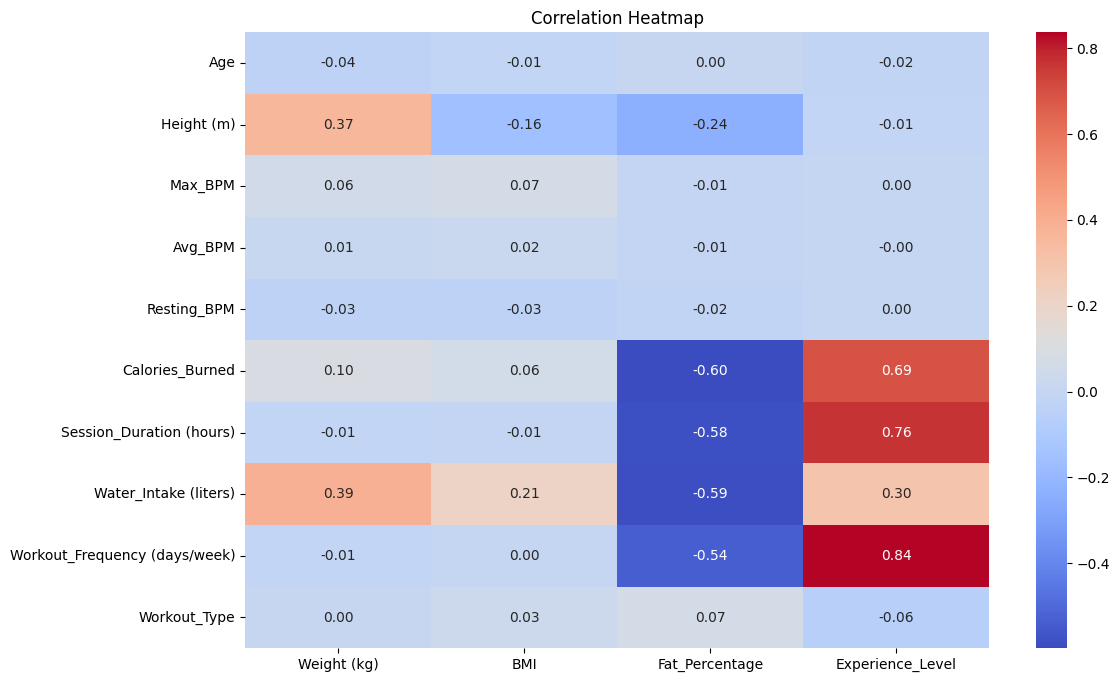

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_results, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

去除噪声

每次运动时长区间与BMI的关系，绘图

Session_Duration (hours)
0-0.5    20.470000
0.5-1    25.028557
1-1.5    24.934753
1.5-2    24.747592
Name: BMI, dtype: float64


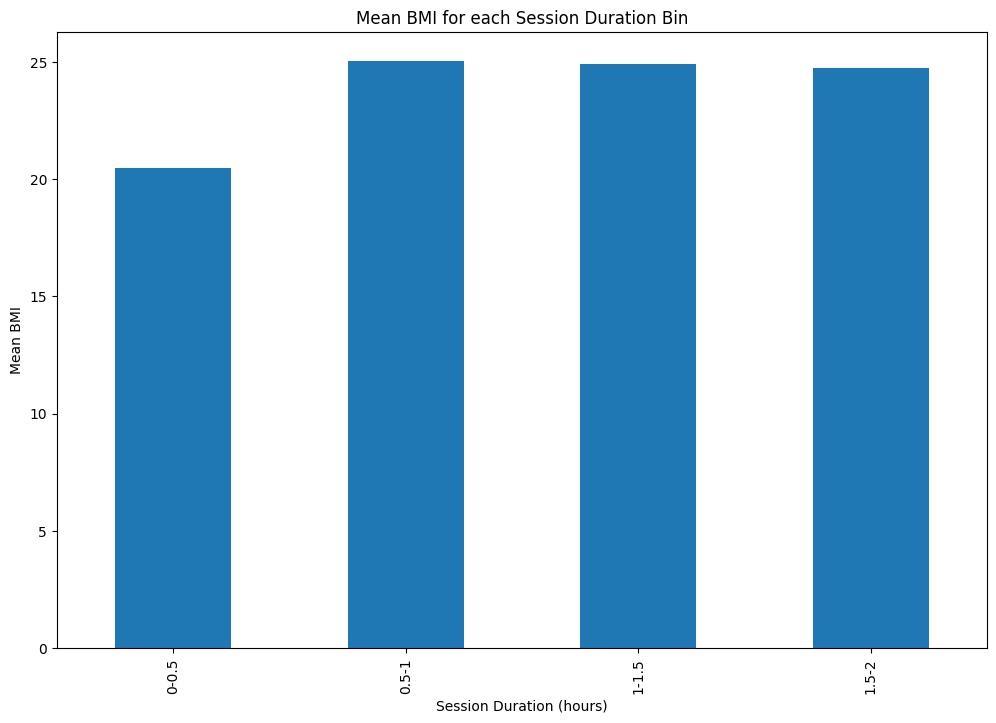

In [16]:

bins = [0, 0.5, 1, 1.5, 2]
labels = ['0-0.5', '0.5-1', '1-1.5', '1.5-2']
session_duration_binned = pd.cut(
    data['Session_Duration (hours)'], bins=bins, labels=labels)
mean_bmi_per_bin = data.groupby(
    session_duration_binned, observed=False)['BMI'].mean()
print(mean_bmi_per_bin)
plt.figure(figsize=(12, 8))
mean_bmi_per_bin.plot(kind='bar')
plt.xlabel('Session Duration (hours)')
plt.ylabel('Mean BMI')
plt.title('Mean BMI for each Session Duration Bin')
plt.show()

每次运动时长与体重的关系绘图

Workout_Frequency (days/week)
2    25.010203
3    24.678370
4    25.253170
5    24.542941
Name: BMI, dtype: float64


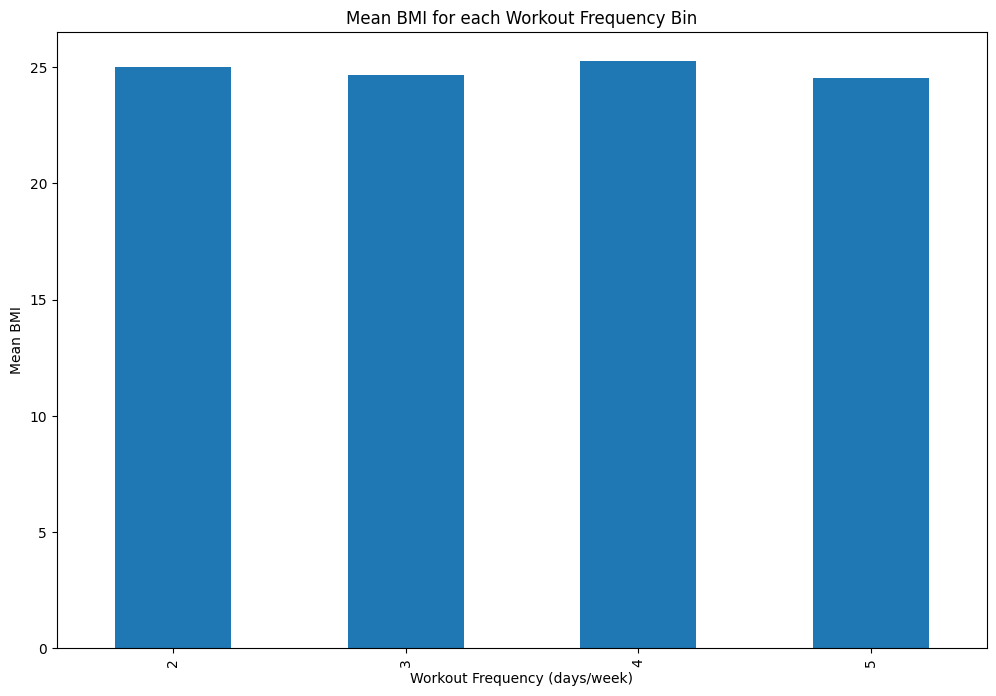

In [17]:
mean_bmi_per_bin = data.groupby('Workout_Frequency (days/week)',observed=False)['BMI'].mean()
print(mean_bmi_per_bin)
plt.figure(figsize=(12, 8))
mean_bmi_per_bin.plot(kind='bar')
plt.xlabel('Workout Frequency (days/week)')
plt.ylabel('Mean BMI')
plt.title('Mean BMI for each Workout Frequency Bin')
plt.show()

筛选喜欢有氧运动且偏肥胖的会员数据

Workout_Frequency (days/week)
2    30.383448
3    30.773529
4    30.159556
5    27.016000
Name: BMI, dtype: float64


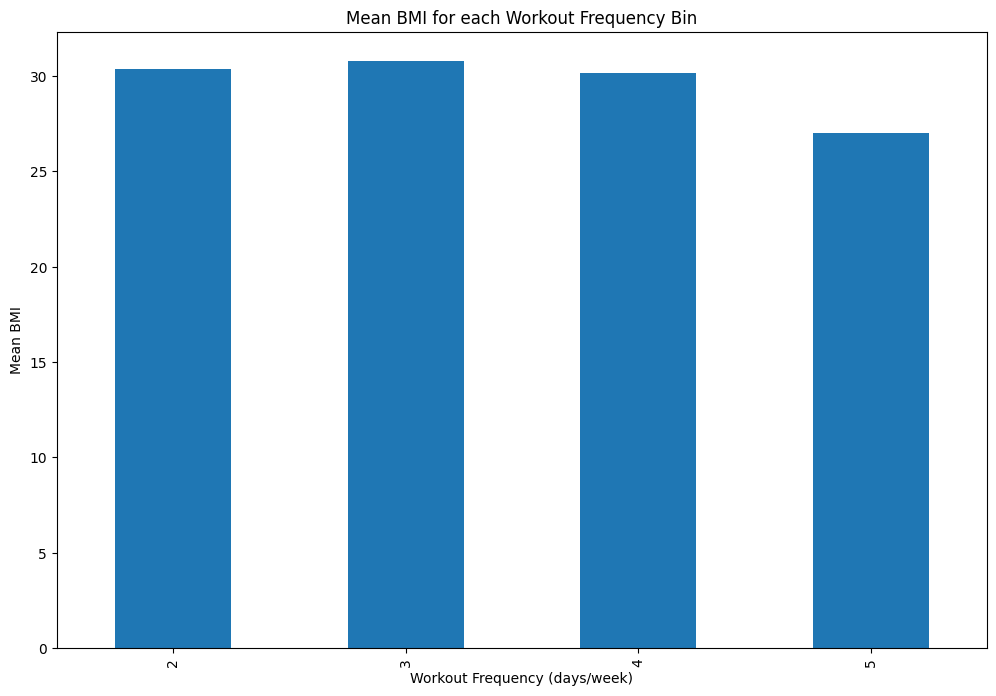

In [18]:
obesity_data = data[data['BMI'] >= 24].loc[data['Workout_Type'] == 4]
mean_bmi_per_bin = obesity_data.groupby(
    'Workout_Frequency (days/week)', observed=False)['BMI'].mean()
print(mean_bmi_per_bin)
plt.figure(figsize=(12, 8))
mean_bmi_per_bin.plot(kind='bar')
plt.xlabel('Workout Frequency (days/week)')
plt.ylabel('Mean BMI')
plt.title('Mean BMI for each Workout Frequency Bin')
plt.show()

Session_Duration_Binned
0.5-1    30.548889
1-1.5    30.735795
1.5-2    27.417000
Name: BMI, dtype: float64


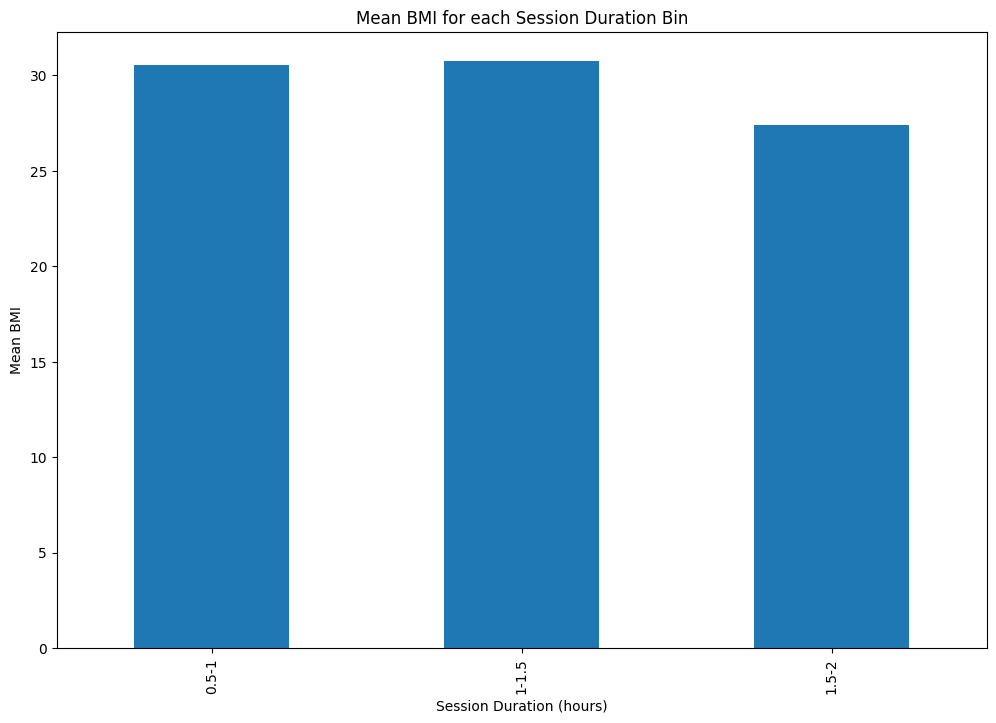

In [19]:
# Define the bins for Session_Duration
bins = [0.5, 1, 1.5, 2]
labels = ['0.5-1', '1-1.5', '1.5-2']
# Create a new column for the binned Session_Duration
obesity_data['Session_Duration_Binned'] = pd.cut(
    obesity_data['Session_Duration (hours)'], bins=bins, labels=labels)
# Calculate the mean BMI for each bin
mean_bmi_per_bin = obesity_data.groupby(
    'Session_Duration_Binned', observed=False)['BMI'].mean()
print(mean_bmi_per_bin)
# Plot the mean BMI for each bin
plt.figure(figsize=(12, 8))
mean_bmi_per_bin.plot(kind='bar')
plt.xlabel('Session Duration (hours)')
plt.ylabel('Mean BMI')
plt.title('Mean BMI for each Session Duration Bin')
plt.show()

各个连续型随机变量的正态分布图

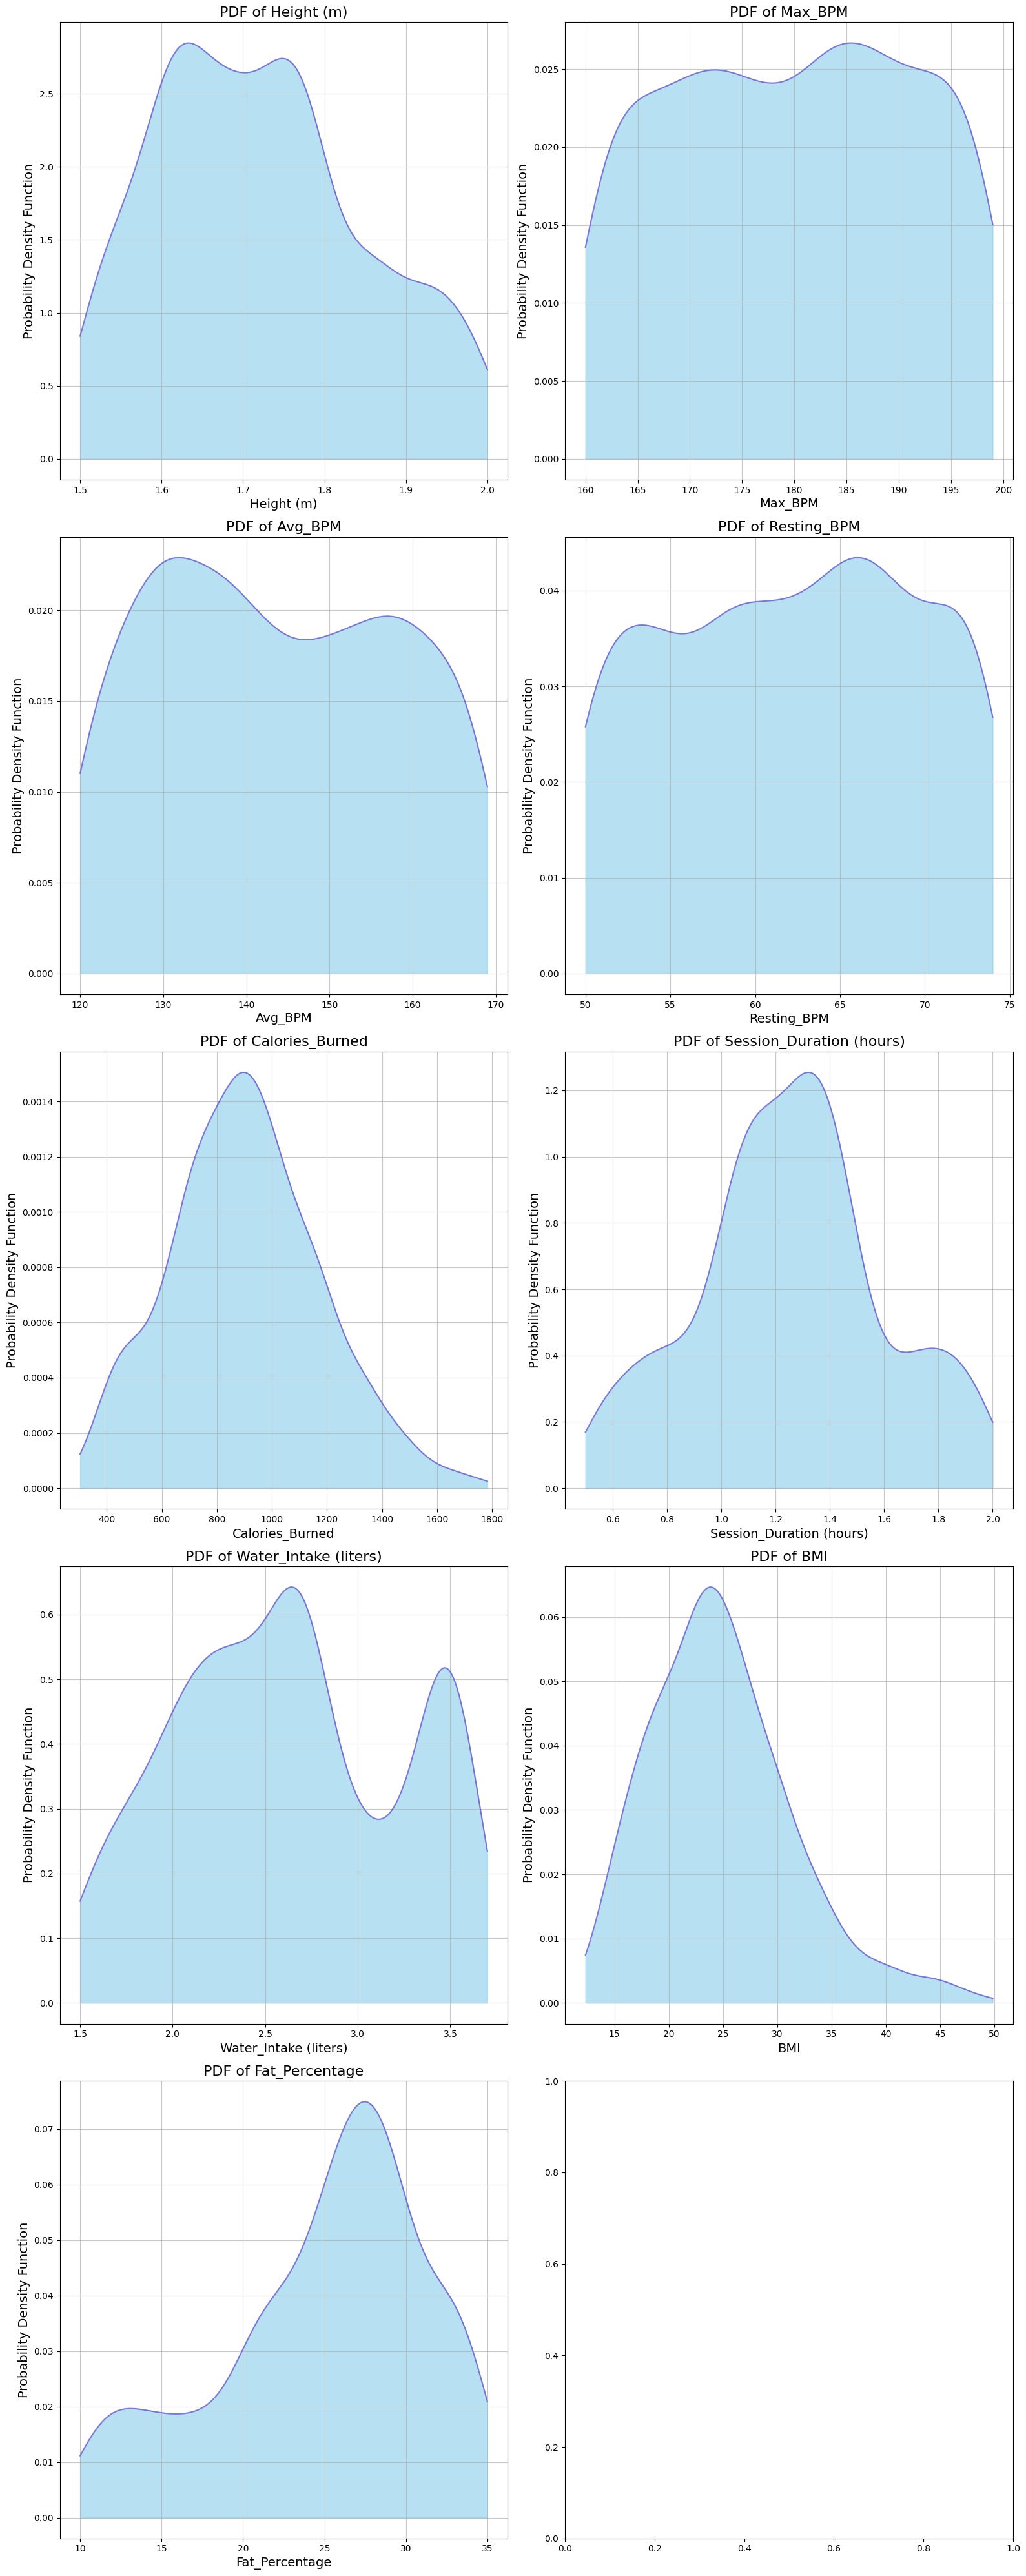

In [ ]:
successive_variables = ['Height (m)', 'Max_BPM', 
                        'Avg_BPM', 'Resting_BPM', 
                        'Calories_Burned', 'Session_Duration (hours)', 
                        'Water_Intake (liters)', 'BMI', 
                        'Fat_Percentage']
fig, axes = plt.subplots(
    len(successive_variables) // 2 + 
    len(successive_variables) % 2, 
    2, figsize=(
        16, 
        8 * (len(successive_variables) // 2 
            + len(successive_variables) % 2)
        ))
# 每行三个图
axes = axes.flatten()
# 绘制每一个连续型变量
for i, var in enumerate(successive_variables):
    x = data[var].dropna()
    kde = scipy.stats.gaussian_kde(x)
    x_range = np.linspace(x.min(), x.max(), 1000)
    # 通过在数据的最大值和最小值之间生成1000个点，可以创建一个平滑的密度曲线，从而更准确地表示数据的概率密度函数。
    y = kde(x_range)
    axes[i].fill_between(x_range, y, color='skyblue', alpha=0.6)
    axes[i].plot(x_range, y, color='Slateblue', alpha=0.8)
    axes[i].set_xlabel(var, fontsize=14)
    axes[i].set_ylabel('Probability Density Function', fontsize=14)
    axes[i].set_title(f'PDF of {var}', fontsize=16)
    axes[i].grid(True, linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()